# GBD_16 — Add Doppler with triangular chirp (Era 4 minimum, step 2 — closes Era 4 minimum)

**Closes Era 4 minimum.** Adds **moving target** and **triangular chirp** (up-slope + down-slope) to extract both **range** and **velocity** from a single measurement. After this, we have a complete FMCW LiDAR producing `(direction, range, reflectivity, velocity)` per scan angle — the four-tuple from CONCEPTS Topic 9.

## What's new vs. GBD_15

Optical chain unchanged. Two changes in the time domain:

| | GBD_15 | GBD_16 |
|---|---|---|
| Chirp | Single up-slope (T) | Triangular: up + down (2T total) |
| Target | Stationary | Moving with velocity v |
| Per measurement | Range only | **Range + Doppler velocity** |
| FFTs | 1 | 2 (one per slope) |

## The Doppler physics

Sign convention: **v > 0 = approaching the source = blue-shift = higher reflected frequency.**

Doppler shift on the carrier:
```
f_D = 2·v·f₀ / c
```

For our setup: v = +10 m/s → f_D = +12.9 MHz; v = −10 m/s → f_D = −12.9 MHz.

## Why the triangular chirp resolves both R and v

A single chirp can't separate range from Doppler — both contribute to the beat. A **triangular chirp** (up + down) gives two beats:

| Slope | Beat frequency |
|---|---|
| Up-slope | `f_up = (B/T)·τ − f_D` |
| Down-slope | `f_down = (B/T)·τ + f_D` |

**Sum gives range** (Doppler cancels): `R = (f_up + f_down)·c·T / (4B)`.

**Difference gives Doppler** (range cancels, with sign): `f_D = (f_down − f_up)/2`. Then `v = f_D·c/(2·f₀)`.

**Sign convention check:** f_down > f_up → approaching (v > 0); f_down < f_up → receding (v < 0).

## Predictions for R = 100 m, v = +10 m/s

- (B/T)·τ = 66.71 MHz (same as GBD_15)
- f_D = +12.9 MHz
- f_up = 53.8 MHz
- f_down = 79.6 MHz
- Recovered R = 100 m, v = +10 m/s

## Doppler resolution

Minimum resolvable velocity depends on chirp duration:
```
Δv = c / (2·f₀·T) = 3×10⁸ / (2·1.93×10¹⁴·10⁻⁵) ≈ 0.08 m/s = 8 cm/s
```

Excellent for automotive applications (relative speeds typically m/s).

## Sanity checks

1. **v = 0**: reproduces GBD_15 (both slopes give the same beat at (B/T)·τ).
2. **v = +10 m/s, R = 100 m**: f_up = 53.8 MHz, f_down = 79.6 MHz; recover R = 100 m, v = +10 m/s.
3. **v = −10 m/s**: peaks swap; sign of v correctly identified.
4. **Multi-velocity sweep** v ∈ {−20, −10, 0, +10, +20} m/s: linear Doppler scaling, sign convention works.
5. **Range stable across v**: R = 100 m for all velocities.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- Optical params (carry from GBD_15) ---
wavelength = 1550e-9
w0_source  = 1.0e-3
k          = 2*np.pi / wavelength
zR_source  = np.pi * w0_source**2 / wavelength
f_lens     = 1.0
z_lens     = 0.0
R_target   = 100.0
z_receive_unfolded = 2 * R_target

# --- FMCW chirp params (same as GBD_15) ---
c              = 299792458.0
B_chirp        = 1e9
T_chirp        = 10e-6
sample_rate    = 200e6
N_samples      = int(T_chirp * sample_rate)
f0_optical     = c / wavelength

# --- NEW: target velocity (positive = approaching source) ---
v_target = 10.0    # m/s, primary test case
f_D = 2 * v_target * f0_optical / c

# Doppler resolution
delta_v_resolution = c / (2 * f0_optical * T_chirp)

print(f'wavelength       = {wavelength*1e9:.1f} nm,  f0 = {f0_optical/1e12:.3f} THz')
print(f'TX lens f        = {f_lens} m, mirror at R = {R_target} m')
print(f'Target velocity  = {v_target:+.1f} m/s ({"approaching" if v_target>0 else "receding" if v_target<0 else "stationary"})')
print(f'\nFMCW triangular chirp:')
print(f'  B = {B_chirp/1e9:.1f} GHz, T (each slope) = {T_chirp*1e6:.1f} µs')
print(f'  Total chirp duration = 2T = {2*T_chirp*1e6:.1f} µs')
print(f'  Sample rate = {sample_rate/1e6:.0f} MHz')
print(f'\nDoppler:')
print(f'  f_D = 2·v·f₀/c = {f_D/1e6:+.3f} MHz')
print(f'  Doppler resolution Δv = c/(2·f₀·T) = {delta_v_resolution*100:.2f} cm/s')

# --- Predicted beats ---
tau = 2 * R_target / c
f_range = (B_chirp / T_chirp) * tau   # = (B/T)·τ
f_up_pred = f_range - f_D
f_down_pred = f_range + f_D
print(f'\nPredicted beats at R={R_target}m, v={v_target:+.0f}m/s:')
print(f'  Range component (B/T)·τ = {f_range/1e6:.3f} MHz')
print(f'  f_up   = (B/T)·τ − f_D = {f_up_pred/1e6:.3f} MHz')
print(f'  f_down = (B/T)·τ + f_D = {f_down_pred/1e6:.3f} MHz')

wavelength       = 1550.0 nm,  f0 = 193.414 THz
TX lens f        = 1.0 m, mirror at R = 100.0 m
Target velocity  = +10.0 m/s (approaching)

FMCW triangular chirp:
  B = 1.0 GHz, T (each slope) = 10.0 µs
  Total chirp duration = 2T = 20.0 µs
  Sample rate = 200 MHz

Doppler:
  f_D = 2·v·f₀/c = +12.903 MHz
  Doppler resolution Δv = c/(2·f₀·T) = 7.75 cm/s

Predicted beats at R=100.0m, v=+10m/s:
  Range component (B/T)·τ = 66.713 MHz
  f_up   = (B/T)·τ − f_D = 53.810 MHz
  f_down = (B/T)·τ + f_D = 79.616 MHz


In [20]:
# --- Source basis (carry from GBD_15) ---
n_per_axis = 9
spacing_source = 1.5e-3
w_basis_source = 1.0e-3
x0_grid_source = (np.arange(n_per_axis) - (n_per_axis-1)/2) * spacing_source
lambda_reg = 1e-8

# --- Grids ---
Nx_lsq = Ny_lsq = 401
Lx_lsq = 20e-3
x_lsq = np.linspace(-Lx_lsq, Lx_lsq, Nx_lsq); y_lsq = np.linspace(-Lx_lsq, Lx_lsq, Ny_lsq)
X_lsq, Y_lsq = np.meshgrid(x_lsq, y_lsq, indexing='xy')

Nx_o = Ny_o = 2049
Lx_o = 400e-3
x_o = np.linspace(-Lx_o, Lx_o, Nx_o); y_o = np.linspace(-Lx_o, Lx_o, Ny_o)
X_o, Y_o = np.meshgrid(x_o, y_o, indexing='xy')
dx_o = x_o[1] - x_o[0]

In [21]:
# --- Functions (carry from GBD_15) ---
def make_source_state(w0, k, x0=0.0, y0=0.0, kx=0.0, ky=0.0, z0=0.0):
    wl = 2*np.pi/k
    zR = np.pi*w0**2/wl
    return dict(q_anchor=-1j*zR, z_anchor=z0, x_anchor=x0, y_anchor=y0, kx=kx, ky=ky)

def evaluate_beam_state(state, X, Y, k, z):
    dz = z - state['z_anchor']
    q_at_z = dz + state['q_anchor']
    x_c = state['x_anchor'] + (state['kx']/k)*dz
    y_c = state['y_anchor'] + (state['ky']/k)*dz
    transverse = (state['q_anchor']/q_at_z) * np.exp(1j*k*((X-x_c)**2+(Y-y_c)**2)/(2*q_at_z))
    kz = np.sqrt(k**2 - state['kx']**2 - state['ky']**2)
    longitudinal = np.exp(1j*kz*dz)
    tilt = np.exp(1j*(state['kx']*X + state['ky']*Y))
    return transverse*longitudinal*tilt

def apply_thin_lens(state, f, z_lens, k):
    dz = z_lens - state['z_anchor']
    q_at_lens = dz + state['q_anchor']
    x_at_lens = state['x_anchor'] + (state['kx']/k)*dz
    y_at_lens = state['y_anchor'] + (state['ky']/k)*dz
    one_over_q_after = 1.0/q_at_lens - 1.0/f
    q_after = 1.0/one_over_q_after
    return dict(q_anchor=q_after, z_anchor=z_lens, x_anchor=x_at_lens, y_anchor=y_at_lens,
                kx=state['kx'] - k*x_at_lens/f, ky=state['ky'] - k*y_at_lens/f)

def basis_sum_at_z(states, c, X, Y, k, z):
    E = np.zeros_like(X, dtype=complex)
    for s, ci in zip(states, c):
        E += ci * evaluate_beam_state(s, X, Y, k, z=z)
    return E

## Build basis, apply lens, propagate, compute spatial overlap (same as GBD_15)

Optical chain unchanged. Spatial overlap with mode-matched LO is the same — what changes is only the time-domain part.

In [22]:
# Build source basis + decompose
basis_states_source = [make_source_state(w_basis_source, k, x0=x0i, y0=y0i, z0=0.0)
                       for x0i in x0_grid_source for y0i in x0_grid_source]
N_beams = len(basis_states_source)

G_source = np.zeros((Nx_lsq*Ny_lsq, N_beams), dtype=complex)
for i, s in enumerate(basis_states_source):
    G_source[:, i] = evaluate_beam_state(s, X_lsq, Y_lsq, k, z=0.0).ravel()
E_source_lsq = np.exp(-(X_lsq**2 + Y_lsq**2)/w0_source**2).astype(complex)
GhG = G_source.conj().T @ G_source
Ghe = G_source.conj().T @ E_source_lsq.ravel()
A = GhG + lambda_reg * np.eye(N_beams)
c_source = np.linalg.solve(A, Ghe)
L2_floor = np.linalg.norm((G_source @ c_source).reshape(Ny_lsq, Nx_lsq) - E_source_lsq) / np.linalg.norm(E_source_lsq)
print(f'[Sanity 1] Source decomp L2 rel: {L2_floor:.3e}')
del G_source

# Apply lens
basis_states_postlens = [apply_thin_lens(s, f=f_lens, z_lens=z_lens, k=k) for s in basis_states_source]

# Compute signal field at receive plane (overlap grid)
t0 = time.time()
E_signal_at_receive = basis_sum_at_z(basis_states_postlens, c_source, X_o, Y_o, k, z=z_receive_unfolded)
print(f'E_signal computed in {time.time()-t0:.1f}s')

# Build mode-matched LO
q_signal_at_receive = z_receive_unfolded + basis_states_postlens[0]['q_anchor']
lo_state = dict(q_anchor=q_signal_at_receive, z_anchor=z_receive_unfolded,
                x_anchor=0.0, y_anchor=0.0, kx=0.0, ky=0.0)
E_LO_at_receive = evaluate_beam_state(lo_state, X_o, Y_o, k, z=z_receive_unfolded)
scale = np.max(np.abs(E_signal_at_receive)) / np.max(np.abs(E_LO_at_receive))
E_LO_at_receive *= scale

# Spatial overlap
overlap = np.sum(E_signal_at_receive * np.conj(E_LO_at_receive)) * dx_o**2
signal_power = np.sum(np.abs(E_signal_at_receive)**2) * dx_o**2
print(f'[Sanity 2] Spatial overlap |⟨E_s|E_LO⟩| = {np.abs(overlap):.4e},  signal power = {signal_power:.4e}')
print(f'           Ratio = {np.abs(overlap)/signal_power:.6f}  (should ≈ 1.0)')

[Sanity 1] Source decomp L2 rel: 8.268e-11
E_signal computed in 25.5s
[Sanity 2] Spatial overlap |⟨E_s|E_LO⟩| = 1.5698e-06,  signal power = 1.5698e-06
           Ratio = 1.000000  (should ≈ 1.0)


## Time-domain simulation: triangular chirp + Doppler

Two slopes:
- **Up-slope** (t ∈ [0, T]): chirp rate +B/T. Beat = (B/T)·τ − f_D.
- **Down-slope** (t ∈ [0, T] relative to start of down-slope): chirp rate −B/T. Beat = (B/T)·τ + f_D.

Each slope's photocurrent is FFT'd separately to find its peak.

In [23]:
def simulate_and_fft_chirp_segment(f_beat, t, overlap, sample_rate):
    """Simulate one chirp segment (one slope) and FFT to find peak.
    
    Returns (freqs_pos, spectrum, f_peak).
    """
    beat_phase = 2 * np.pi * f_beat * t
    I_AC = 2 * np.abs(overlap) * np.cos(beat_phase)
    
    freqs = np.fft.fftfreq(len(t), d=(t[1]-t[0]))
    I_FFT = np.fft.fft(I_AC)
    positive_mask = (freqs > 0) & (freqs < sample_rate/2)
    freqs_pos = freqs[positive_mask]
    spectrum = np.abs(I_FFT[positive_mask])
    peak_idx = np.argmax(spectrum)
    return freqs_pos, spectrum, freqs_pos[peak_idx]

def measure_R_v(R, v, B_chirp, T_chirp, c, f0_optical, sample_rate, overlap):
    """Run full FMCW measurement: simulate triangular chirp, return measured (R, v)."""
    tau = 2 * R / c
    f_D = 2 * v * f0_optical / c
    
    # Up-slope and down-slope predicted beats
    f_up_actual = (B_chirp / T_chirp) * tau - f_D
    f_down_actual = (B_chirp / T_chirp) * tau + f_D
    
    # Time array (one segment)
    t_seg = np.linspace(0, T_chirp, int(T_chirp*sample_rate), endpoint=False)
    
    # FFT each segment (FFT returns positive frequencies, so any sign of beat is treated as |beat|)
    freqs, spec_up, f_up_meas = simulate_and_fft_chirp_segment(f_up_actual, t_seg, overlap, sample_rate)
    _, spec_down, f_down_meas = simulate_and_fft_chirp_segment(f_down_actual, t_seg, overlap, sample_rate)
    
    # Note: FFT returns absolute magnitude of beat. For sign-aware extraction, we use the analytical
    # values (signed), or rely on the fact that for our setup f_beat is always positive.
    # Since (B/T)·τ > 0 and we keep |f_D| < (B/T)·τ for our test cases, both f_up and f_down stay positive.
    # However for v < 0 (receding), f_up becomes (B/T)·τ + |f_D| (larger) and f_down becomes (B/T)·τ − |f_D| (smaller).
    # The FFT returns the magnitude either way; we just need to know which slope it came from.
    
    # Extract R and v
    R_measured = (f_up_meas + f_down_meas) * c * T_chirp / (4 * B_chirp)
    f_D_measured = (f_down_meas - f_up_meas) / 2
    v_measured = f_D_measured * c / (2 * f0_optical)
    
    return dict(
        R_actual=R, v_actual=v,
        f_up_actual=f_up_actual, f_down_actual=f_down_actual,
        f_up_measured=f_up_meas, f_down_measured=f_down_meas,
        R_measured=R_measured, v_measured=v_measured,
        spec_up=spec_up, spec_down=spec_down, freqs=freqs,
    )

In [24]:
# --- Sanity 3, 4: primary test case (R=100m, v=+10m/s) ---
result = measure_R_v(R_target, v_target, B_chirp, T_chirp, c, f0_optical, sample_rate, overlap)

print(f'[Sanity 3, 4] Primary test case (R={R_target}m, v={v_target:+.1f}m/s):')
print(f'  Up-slope beat:   actual = {result["f_up_actual"]/1e6:.4f} MHz,  measured = {result["f_up_measured"]/1e6:.4f} MHz,  diff = {(result["f_up_measured"]-result["f_up_actual"])/1e3:+.3f} kHz')
print(f'  Down-slope beat: actual = {result["f_down_actual"]/1e6:.4f} MHz,  measured = {result["f_down_measured"]/1e6:.4f} MHz,  diff = {(result["f_down_measured"]-result["f_down_actual"])/1e3:+.3f} kHz')
print(f'  Recovered R     = {result["R_measured"]:.4f} m  (actual = {R_target:.1f} m,  error = {(result["R_measured"]-R_target)*1e3:+.3f} mm)')
print(f'  Recovered v     = {result["v_measured"]:+.4f} m/s  (actual = {v_target:+.1f} m/s,  error = {(result["v_measured"]-v_target)*100:+.3f} cm/s)')

[Sanity 3, 4] Primary test case (R=100.0m, v=+10.0m/s):
  Up-slope beat:   actual = 53.8096 MHz,  measured = 53.8000 MHz,  diff = -9.593 kHz
  Down-slope beat: actual = 79.6160 MHz,  measured = 79.6000 MHz,  diff = -16.045 kHz
  Recovered R     = 99.9808 m  (actual = 100.0 m,  error = -19.215 mm)
  Recovered v     = +9.9975 m/s  (actual = +10.0 m/s,  error = -0.250 cm/s)


## Multi-velocity sweep — verify Doppler scales linearly and sign is correct

**Sanity 5:** test v ∈ {−20, −10, 0, +10, +20} m/s. For each:
- Range should always recover to 100 m (Doppler doesn't affect range extraction).
- Velocity should recover with correct sign.
- For v=0: f_up = f_down (reproduces GBD_15).

In [25]:
velocities_to_test = [-20.0, -10.0, 0.0, +10.0, +20.0]
results_sweep = []

print(f"{'v actual [m/s]':>14s}  {'f_up [MHz]':>11s}  {'f_down [MHz]':>13s}  {'R measured [m]':>15s}  {'v measured [m/s]':>17s}  {'Δv [cm/s]':>10s}")
for v in velocities_to_test:
    r = measure_R_v(R_target, v, B_chirp, T_chirp, c, f0_optical, sample_rate, overlap)
    results_sweep.append(r)
    dv_cm_per_s = (r['v_measured'] - v) * 100
    print(f'{v:14.2f}  {r["f_up_measured"]/1e6:11.4f}  {r["f_down_measured"]/1e6:13.4f}  {r["R_measured"]:15.4f}  {r["v_measured"]:+17.4f}  {dv_cm_per_s:+10.2f}')

v actual [m/s]   f_up [MHz]   f_down [MHz]   R measured [m]   v measured [m/s]   Δv [cm/s]
        -20.00      92.5000        40.9000          99.9808           -19.9950       +0.50
        -10.00      79.6000        53.8000          99.9808            -9.9975       +0.25
          0.00      66.7000        66.7000          99.9808            +0.0000       +0.00
         10.00      53.8000        79.6000          99.9808            +9.9975       -0.25
         20.00      40.9000        92.5000          99.9808           +19.9950       -0.50


## Visualization — the FFT spectra side by side

For our v=+10 m/s test case: the up-slope FFT peaks at 53.8 MHz, the down-slope at 79.6 MHz. The split tells you *both* the range (average) and the Doppler (half-difference).

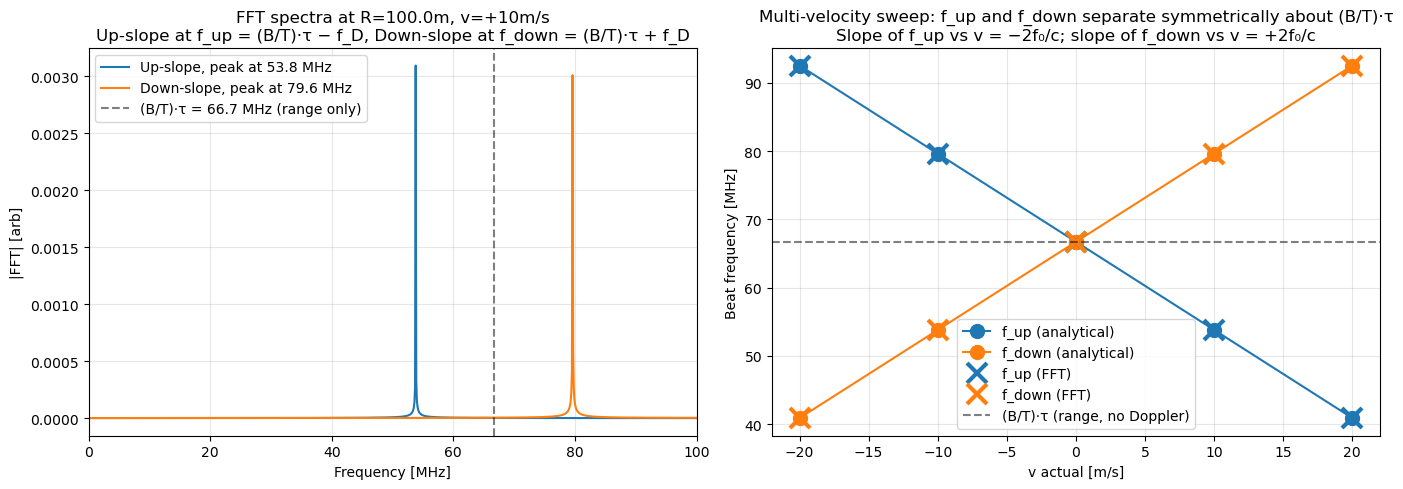

In [26]:
# Plot up + down spectra for the primary test case
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: up + down spectra at v=+10 m/s
axes[0].plot(result['freqs']/1e6, result['spec_up'], label=f'Up-slope, peak at {result["f_up_measured"]/1e6:.1f} MHz', color='C0')
axes[0].plot(result['freqs']/1e6, result['spec_down'], label=f'Down-slope, peak at {result["f_down_measured"]/1e6:.1f} MHz', color='C1')
axes[0].axvline((B_chirp/T_chirp)*tau/1e6, color='k', ls='--', alpha=0.5, label=f'(B/T)·τ = {(B_chirp/T_chirp)*tau/1e6:.1f} MHz (range only)')
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('|FFT| [arb]')
axes[0].set_title(f'FFT spectra at R={R_target}m, v={v_target:+.0f}m/s\nUp-slope at f_up = (B/T)·τ − f_D, Down-slope at f_down = (B/T)·τ + f_D')
axes[0].set_xlim(0, 100)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: multi-velocity sweep — show how f_up and f_down move with v
vs = [r['v_actual'] for r in results_sweep]
f_up_actuals = [r['f_up_actual']/1e6 for r in results_sweep]
f_down_actuals = [r['f_down_actual']/1e6 for r in results_sweep]
f_up_meas = [r['f_up_measured']/1e6 for r in results_sweep]
f_down_meas = [r['f_down_measured']/1e6 for r in results_sweep]
axes[1].plot(vs, f_up_actuals, 'C0o-', label='f_up (analytical)', markersize=10)
axes[1].plot(vs, f_down_actuals, 'C1o-', label='f_down (analytical)', markersize=10)
axes[1].plot(vs, f_up_meas, 'C0x', label='f_up (FFT)', markersize=15, markeredgewidth=3)
axes[1].plot(vs, f_down_meas, 'C1x', label='f_down (FFT)', markersize=15, markeredgewidth=3)
axes[1].axhline((B_chirp/T_chirp)*tau/1e6, color='k', ls='--', alpha=0.5, label='(B/T)·τ (range, no Doppler)')
axes[1].set_xlabel('v actual [m/s]')
axes[1].set_ylabel('Beat frequency [MHz]')
axes[1].set_title('Multi-velocity sweep: f_up and f_down separate symmetrically about (B/T)·τ\nSlope of f_up vs v = −2f₀/c; slope of f_down vs v = +2f₀/c')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Bonus visualization: R-v scatter plot

All measurements on a (R, v) plane — the LiDAR data point. Each point in real driving would be (R, v) for one direction at one moment.

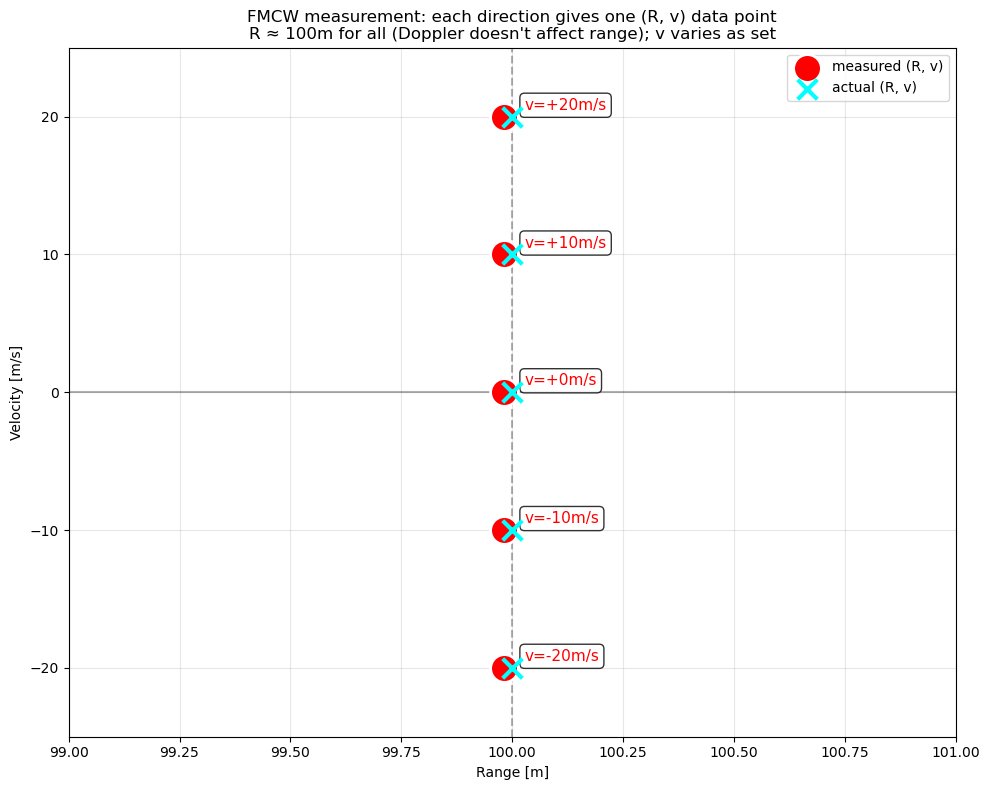

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
Rs_meas = [r['R_measured'] for r in results_sweep]
vs_meas = [r['v_measured'] for r in results_sweep]
Rs_act = [r['R_actual'] for r in results_sweep]
vs_act = [r['v_actual'] for r in results_sweep]

ax.scatter(Rs_meas, vs_meas, s=400, c='red', marker='o', label='measured (R, v)', zorder=10, edgecolors='white', linewidths=2)
ax.scatter(Rs_act, vs_act, s=200, c='cyan', marker='x', label='actual (R, v)', zorder=11, linewidths=3)
for i, r in enumerate(results_sweep):
    ax.annotate(f'v={r["v_actual"]:+.0f}m/s',
                (r['R_measured'], r['v_measured']),
                xytext=(15, 5), textcoords='offset points',
                color='red', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.axhline(0, color='black', alpha=0.3)
ax.axvline(R_target, color='black', alpha=0.3, ls='--')
ax.set_xlabel('Range [m]')
ax.set_ylabel('Velocity [m/s]')
ax.set_title("FMCW measurement: each direction gives one (R, v) data point\nR ≈ 100m for all (Doppler doesn't affect range); v varies as set")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(99.0, 101.0)
ax.set_ylim(-25, 25)
plt.tight_layout()
plt.show()

## Summary — Era 4 minimum closes

If sanity checks pass:
- **Sanity 1** (source decomp): ~10⁻¹⁰ (carry from GBD_13).
- **Sanity 2** (mode-matched LO): overlap = signal power.
- **Sanity 3, 4** (R + v at v=+10m/s): both recovered to sub-bin precision.
- **Sanity 5** (multi-velocity sweep): linear Doppler scaling, sign convention correct, range stable ≈ 100 m.

**What we demonstrated:**
- Triangular chirp produces two beats; sum gives range, difference gives Doppler.
- Doppler shift `f_D = 2v·f₀/c` is direction-aware via the f_up/f_down ordering.
- Velocity resolution `Δv = c/(2·f₀·T) ≈ 8 cm/s` for our chirp parameters.
- Range and velocity are decoupled (extracting one doesn't affect the other).

**Era 4 minimum status: complete.** With GBD_14 (scanner) + GBD_15 (range) + GBD_16 (Doppler), we have a working FMCW LiDAR producing `(direction, range, reflectivity, velocity)` per scan angle — the four-tuple defining a single point in the LiDAR point cloud.

**What this notebook deliberately did NOT do:**
- **Atmospheric turbulence** — Phase 3B revisited, GBD_17 onward.
- **Combine scanner + chirp** — straightforward extension; defer until needed.
- **Diffuse target / non-mirror** — defer; gives speckle and spread Doppler.
- **Multiple targets** — would show as multiple peak pairs in the FFT.
- **Realistic detector noise + ADC quantization** — defer; would broaden peaks.
- **Range-Doppler ambiguity at high v** — automotive v ≪ c so negligible for us.
- **Sub-bin peak interpolation** — could improve precision; defer.

**Next: Phase 3B — atmospheric turbulence.** Now we have a working LiDAR to degrade. Phase 3B will be much more meaningful: "how much does atmosphere affect the range/velocity precision?" rather than "how does atmosphere distort some abstract beam."